# Pan-Cancer Master Regulator Analysis

### Inputs / Parameters
*This section documents explicit inputs for reproducibility.*
- **Data files:** `output/[cancer]_results/primary_vs_metastasis_[cancer]_results_DE_metabolic_targets.csv`

### Goal
Determine the top transcription factors that are master transcriptional regulators of the dynamically computed pan-cancer metastatic metabolic signature.

### Purpose
To identify if the pan-cancer conserved metabolic targets share common transcriptional regulation.
**Interpretation Guide:** If a specific transcription factor (e.g. NR1D2, MYC, etc.) is highly enriched as a regulator for these genes, it provides strong evidence to hypothesize that it may drive the shared metabolic reprogramming required for metastasis.


In [ ]:
import pandas as pd
import os
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns

import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

try:
    BASE_DIR = os.path.abspath(os.path.dirname(__file__))
    if os.path.basename(BASE_DIR) == 'scripts':
        BASE_DIR = os.path.dirname(BASE_DIR)
except NameError:
    BASE_DIR = os.path.abspath('.')
    if os.path.basename(BASE_DIR) == 'scripts':
        BASE_DIR = os.path.dirname(BASE_DIR)

OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
RESULTS_DIR = os.path.join(OUTPUT_DIR, 'master_regulator_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

import sys
import os

sys.path.append(os.path.abspath(".."))
from pan_cancer_config import CANCERS_TO_RUN as CANCERS
ENRICHR_LIBRARIES = [
    'ChEA_2022',
    'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X',
    'TRRUST_Transcription_Factors_2019'
]


In [ ]:
TARGET_GENES = ['KLRG1', 'GCNT4', 'SLC5A5', 'CYP2E1', 'CD48', 'CD1D', 'AGER', 'CNR2', 'CCR9', 'PTGDR', 'KCTD8', 'CYP19A1']
print(f"Dynamically resolved {len(TARGET_GENES)} pan-cancer upregulated metabolic genes.")
print(f"Genes investigated: {TARGET_GENES}")

# Run enrichment analysis
add_list_url = 'https://maayanlab.cloud/Enrichr/addList'
payload = {
    'list': (None, '\n'.join(TARGET_GENES)),
    'description': (None, 'Pan-Cancer Metabolic Targets')
}
response = requests.post(add_list_url, files=payload)
if not response.ok:
    raise Exception('Error analyzing gene list with Enrichr')

data = json.loads(response.text)
user_list_id = data['userListId']

all_results = []
for lib in ENRICHR_LIBRARIES:
    print(f"Querying Enrichr library: {lib}...")
    enrich_url = f'https://maayanlab.cloud/Enrichr/enrich?userListId={user_list_id}&backgroundType={lib}'
    res = requests.get(enrich_url)
    if not res.ok:
        print(f"Error fetching {lib}")
        continue
        
    results = json.loads(res.text)[lib]
    for row in results:
        term = row[1]
        pval = row[2]
        adj_pval = row[6]
        combined_score = row[4]
        overlap = row[5]
        
        tf_name = term.split('_')[0].split(' ')[0].upper()
        
        all_results.append({
            'Library': lib,
            'Term': term,
            'Transcription Factor': tf_name,
            'P-value': pval,
            'Adjusted P-value': adj_pval,
            'Combined Score': combined_score,
            'Overlapping Genes': ','.join(overlap)
        })
        
df_enrich = pd.DataFrame(all_results)
csv_path = os.path.join(RESULTS_DIR, 'tf_enrichment_results.csv')
df_enrich.to_csv(csv_path, index=False)
print(f"Saved TF enrichment results to {csv_path}\n")

display(df_enrich.head(10))


Dynamically resolved 12 pan-cancer upregulated metabolic genes.
Genes investigated: ['KLRG1', 'GCNT4', 'SLC5A5', 'CYP2E1', 'CD48', 'CD1D', 'AGER', 'CNR2', 'CCR9', 'PTGDR', 'KCTD8', 'CYP19A1']
Querying Enrichr library: ChEA_2022...
Querying Enrichr library: ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X...
Querying Enrichr library: TRRUST_Transcription_Factors_2019...
Saved TF enrichment results to /Users/sakuramaezono/Library/CloudStorage/OneDrive-YokohamaCityUniversity/Personal/05_Python_repositories/metabConnectomeDB/output/master_regulator_results/tf_enrichment_results.csv



,Library,Term,Transcription Factor,P-value,Adjusted P-value,Combined Score,Overlapping Genes
0,ChEA_2022,REST 19997604 ChIP-ChIP NEURONS Mouse,REST,0.003104,0.543592,50.015318,"KCTD8,CYP2E1,CYP19A1,KLRG1"
1,ChEA_2022,RELA 24523406 ChIP-Seq FIBROSARCOMA Human,RELA,0.003198,0.543592,49.326479,"CD48,CYP2E1,AGER,CYP19A1"
2,ChEA_2022,SUZ12 18692474 ChIP-Seq MESCs Mouse,SUZ12,0.010279,0.560098,27.671099,"KCTD8,CCR9,SLC5A5,PTGDR"
3,ChEA_2022,SA1 27219007 Chip-Seq Bcells Human,SA1,0.012862,0.560098,24.532078,"CNR2,CD1D,CYP2E1,PTGDR"
4,ChEA_2022,RUNX1 20887958 ChIP-Seq HPC-7 Mouse,RUNX1,0.013441,0.560098,31.680709,"CNR2,GCNT4,CD48"
5,ChEA_2022,JARID2 20075857 ChIP-Seq MESCs Mouse,JARID2,0.022508,0.560098,22.763246,"KCTD8,CCR9,GCNT4"
6,ChEA_2022,RNF2 18974828 ChIP-Seq MESCs Mouse,RNF2,0.023133,0.560098,22.352168,"KCTD8,CCR9,CYP19A1"
7,ChEA_2022,EZH2 18974828 ChIP-Seq MESCs Mouse,EZH2,0.023133,0.560098,22.352168,"KCTD8,CCR9,CYP19A1"
8,ChEA_2022,BACH1 22875853 ChIP-PCR HELA AND SCP4 Human,BACH1,0.026773,0.560098,20.253400,"CD48,CD1D,CYP2E1"
9,ChEA_2022,RUNX 20019798 ChIP-Seq JUKART Human,RUNX,0.035521,0.560098,25.858300,"CCR9,CD1D"


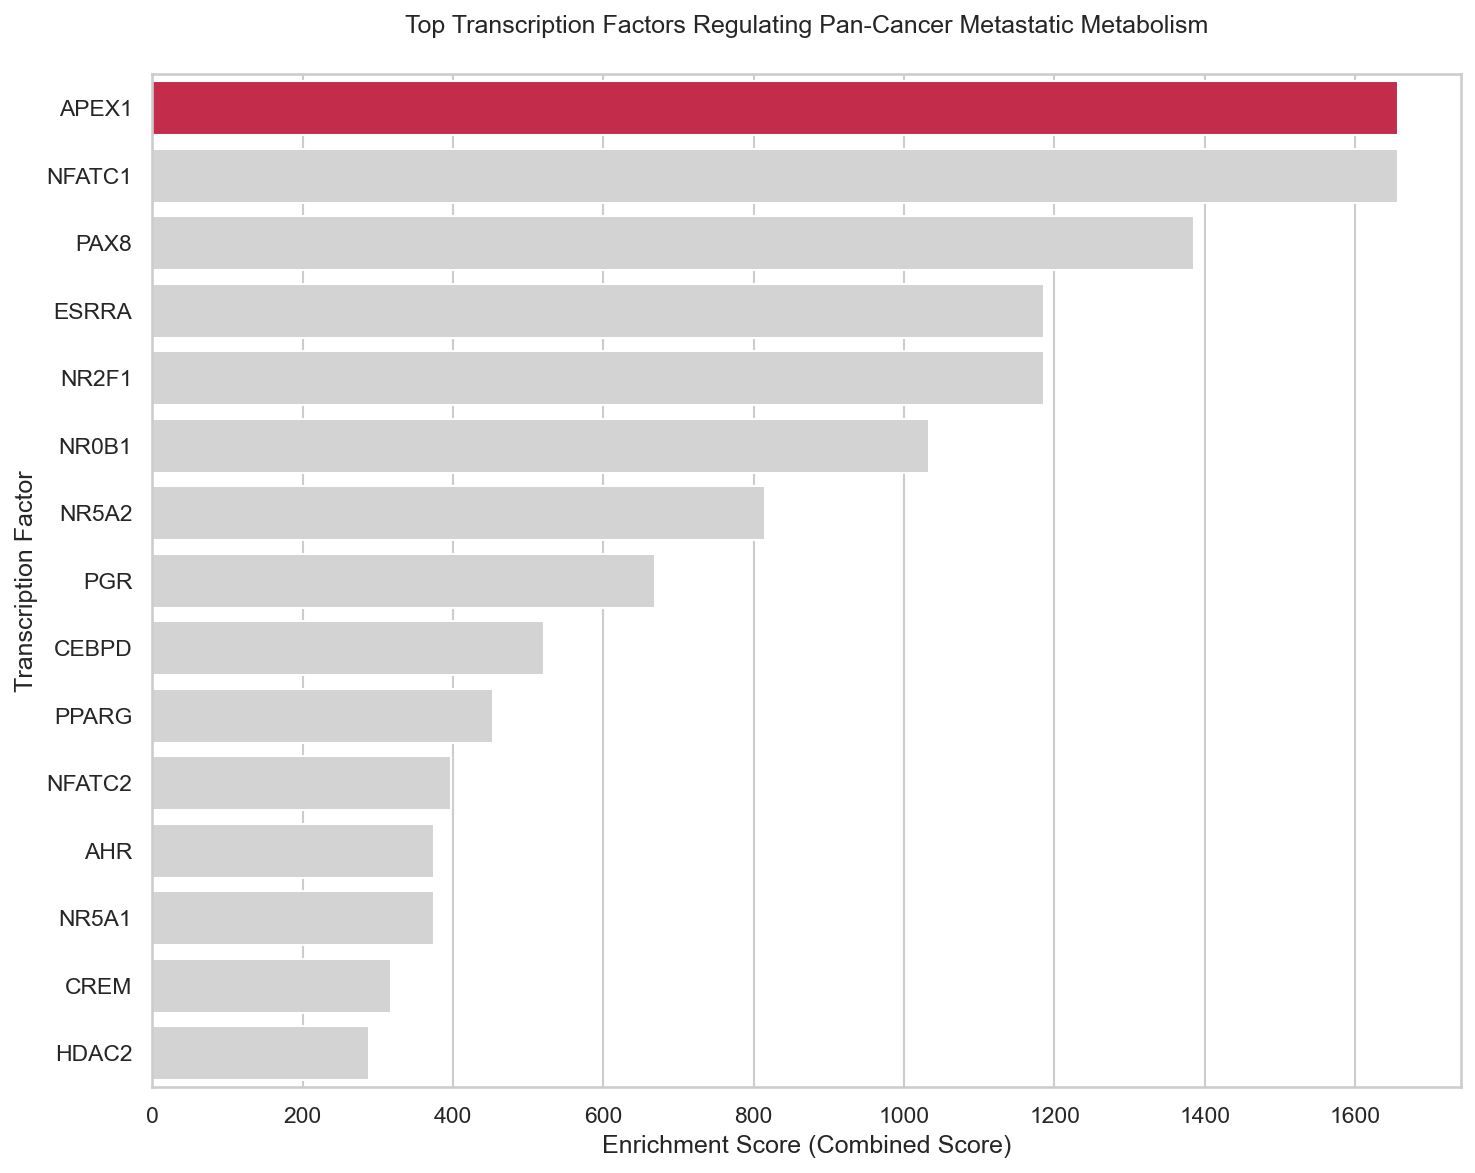

In [ ]:
top_tfs = df_enrich.sort_values('Combined Score', ascending=False).drop_duplicates(subset=['Transcription Factor']).head(15)

# Dynamically highlight the top transcription factor
if not top_tfs.empty:
    top_tf = top_tfs.iloc[0]['Transcription Factor']
    palette = ['crimson' if tf == top_tf else 'lightgray' for tf in top_tfs['Transcription Factor']]
else:
    palette = 'lightgray'

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_tfs, y='Transcription Factor', x='Combined Score',
    palette=palette
)
plt.title('Top Transcription Factors Regulating Pan-Cancer Metastatic Metabolism', pad=20)
plt.xlabel('Enrichment Score (Combined Score)')
plt.ylabel('Transcription Factor')
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, 'top_tfs_barplot.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import subprocess
import sys
import os

notebook_filename = 'master_regulator_analysis.ipynb'
output_base = 'master_regulator_analysis' + '_6MetCan_500k'
output_dir = RESULTS_DIR

jupyter_bin = os.path.join(os.path.dirname(sys.executable), 'jupyter')
if not os.path.exists(jupyter_bin): jupyter_bin = 'jupyter'

cmd_html = [jupyter_bin, "nbconvert", "--to", "html", "--execute", notebook_filename, "--output-dir", output_dir, "--output", output_base]
print("To automatically export to HTML, run the above command in your terminal.")
